## GPU Availability

I have 5090, we should be fine.

In [2]:
!nvidia-smi

Mon Nov  3 13:37:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:01:00.0 Off |                  N/A |
|  0%   42C    P8             10W /  600W |     339MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
os.getcwd()

'/home/iqbal/repos/purwadhika-ai-engineer/capstone-module-4/training'

In [4]:
!ls -l dataset/

total 24
-rw-r--r-- 1 iqbal iqbal  172 Oct 12 18:57 README.dataset.txt
-rw-r--r-- 1 iqbal iqbal  900 Oct 12 18:57 README.roboflow.txt
-rw-r--r-- 1 iqbal iqbal  322 Oct 12 18:57 data.yaml
drwxr-xr-x 4 iqbal iqbal 4096 Oct 12 18:57 test
drwxr-xr-x 4 iqbal iqbal 4096 Oct 12 18:57 train
drwxr-xr-x 4 iqbal iqbal 4096 Oct 12 18:57 valid


In [6]:
!cat dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['bus', 'car', 'van']

roboflow:
  workspace: personal-project-kej16
  project: vehicle-detection-vznzd-dkl8g
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g/dataset/1

In [7]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

--2025-11-03 13:42:10--  https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/99db71db-0946-4c10-94a0-b54baf471037?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-03T07%3A25%3A16Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-03T06%3A24%3A28Z&ske=2025-11-03T07%3A25%3A16Z&sks=b&skv=2018-11-09&sig=BSBMfFvwY7H0Ooxm75ZBtl9BFQAkK42oR5bmG6oppzo%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MjE1MjQzMCwibmJmIjoxNzYyMTUyMTMwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLm

In [11]:
from ultralytics import YOLO

model = YOLO('yolov12n.pt')

In [12]:
results = model.train(
        data='dataset/data.yaml', # Using 20 epochs for faster training
        epochs=40,
        batch=32,
        imgsz=640,
        exist_ok=True,
        patience=5,              # Early stopping if no improvement for 5 epochs
        save_period=5,           # Save checkpoints every 5 epochs
        val=True,                # Ensure validation is performed
        verbose=True,            # Show detailed output during training
        flipud=0.5,              # Augmentation using vertical flip probability
)

Ultralytics 8.3.223 🚀 Python-3.13.7 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32107MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=

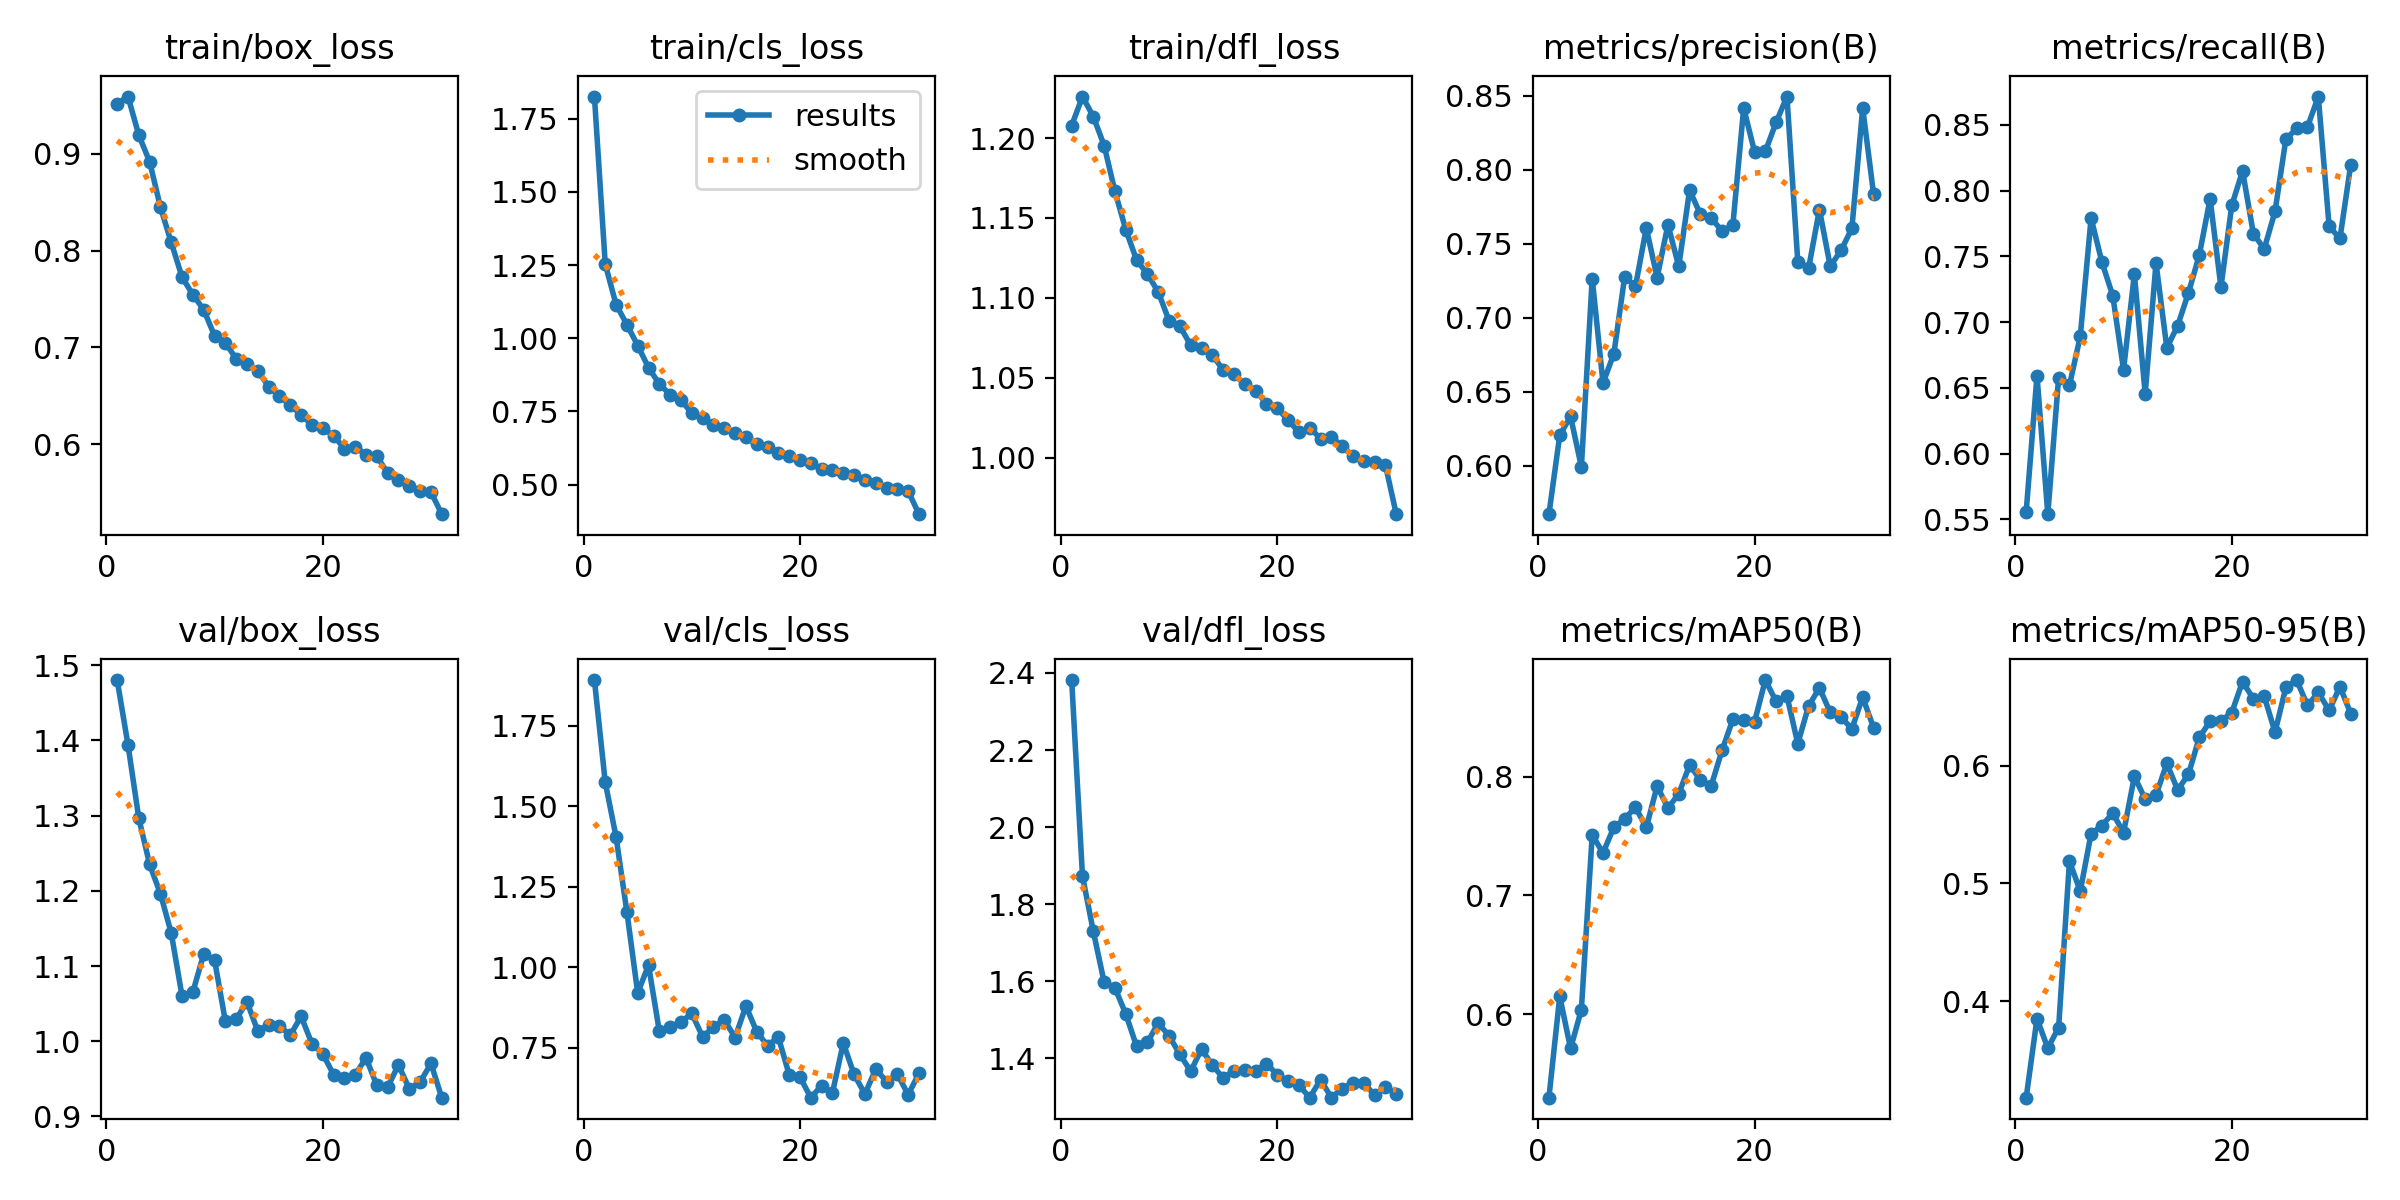

In [15]:
from IPython.display import Image

Image(filename='../../runs/detect/train/results.png', width=1000)

In [16]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path="dataset/test/images",
    annotations_directory_path="dataset/test/labels",
    data_yaml_path="dataset/data.yaml"
)

ds.classes

['bus', 'car', 'van']

In [17]:
from supervision.metrics import MeanAveragePrecision

model = YOLO('best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [28]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.6253515219547195
mAP 50 0.8070259743727624
mAP 75 0.6880445348749167


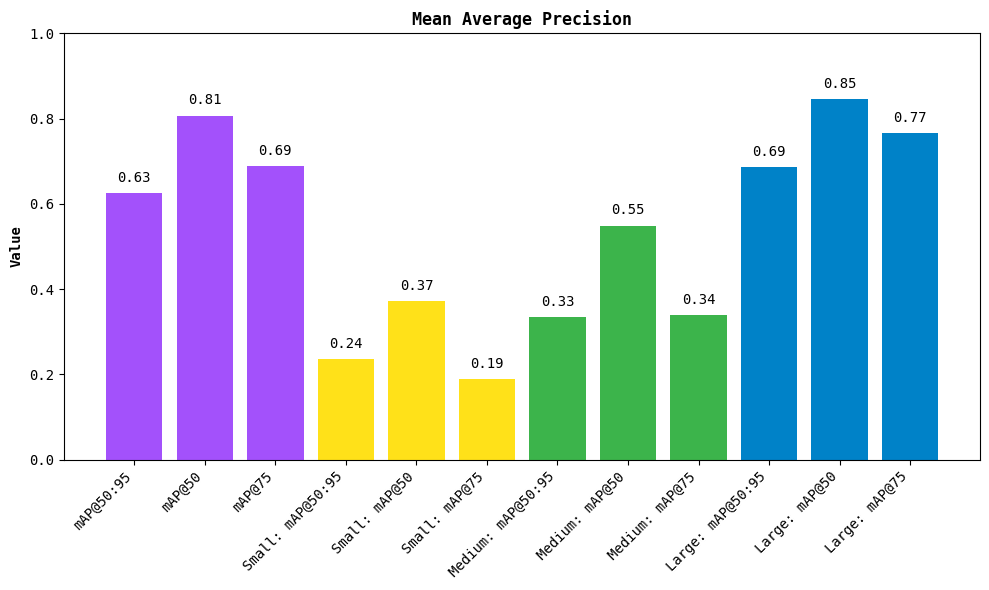

In [38]:
%matplotlib inline
map.plot()

In [39]:
import supervision as sv

model = YOLO(f'best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path="dataset/test/images",
    annotations_directory_path="dataset/test/labels",
    data_yaml_path="dataset/data.yaml"
)

In [52]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

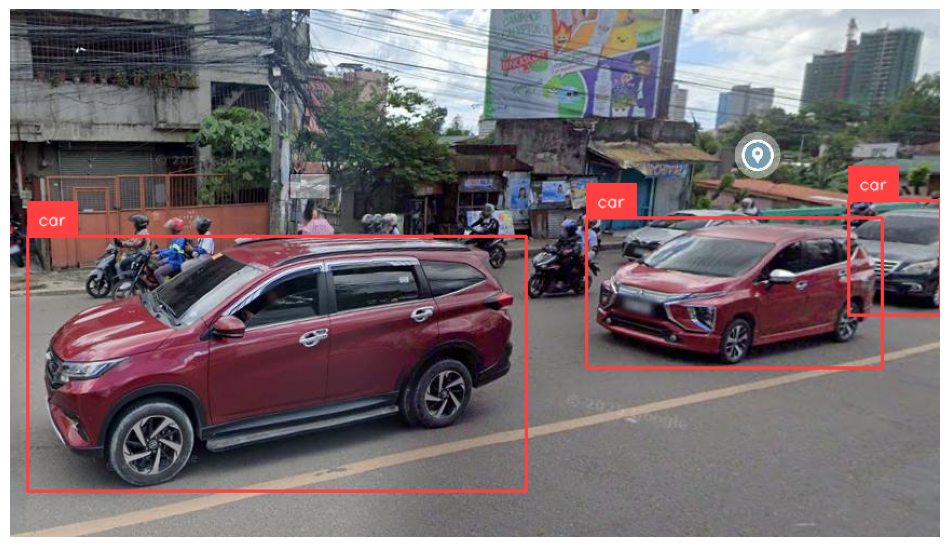

In [53]:
sv.plot_image(annotated_image)